# Week 2 - Checkpoint 1: Descriptive Statistics for Groups
### Dataset: `cars.csv`
https://www.kaggle.com/datasets/sehriyarmemmedli/turboaz-cars-project

**Note:** Before doing any t-test or ANOVA, the data needs to be clean first. If I don't fix duplicates, mixed currencies, and weird units, my stats won't mean anything. So most of this checkpoint is just cleaning.

## 1. Loading the data

The file is huge (650K+ rows), so I only load the columns I actually need with usecols to save memory.

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import skew

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 150)

In [3]:
cols = [
    "id_x", "car_rel_url_x", "datetime_scrape", "price_x", "currency_x", "city",
    "production_year", "engine_displacement_num", "kilometrage_num", "Marka", "Model",
    "Sürətlər qutusu", "Vəziyyəti", "Ötürücü", "Ban növü", "views"
]

In [4]:
df = pd.read_csv("cars.csv", usecols = cols, parse_dates = ["datetime_scrape"])
print("Initial shape:", df.shape)


Initial shape: (653721, 16)


In [5]:
df.head()

,id_x,car_rel_url_x,datetime_scrape,price_x,currency_x,city,production_year,engine_displacement_num,kilometrage_num,views,Ban növü,Marka,Model,Sürətlər qutusu,Vəziyyəti,Ötürücü
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,15000.0,AZN,bakı,2008,1.6,270000,492,"Hetçbek, 5 qapı",Hyundai,i30,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Ön
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,23700.0,AZN,bakı,2024,1.7,0,60189,"Offroader / SUV, 5 qapı",LADA (VAZ),Niva Travel,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Tam
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,35600.0,$,bakı,2011,4.0,164750,2473,"Offroader / SUV, 5 qapı",Toyota,Land Cruiser,Avtomat,"Vuruğu yoxdur, rənglənməyib",Tam
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,26700.0,AZN,bakı,2018,2.0,126000,3727,Sedan,Hyundai,Elantra,Avtomat,"Vuruğu yoxdur, rənglənməyib",Ön
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyota-prius,2024-09-13 20:32:19.751157+00,10500.0,AZN,bakı,2007,1.5,354000,446,Liftbek,Toyota,Prius,Variator,"Vuruğu yoxdur, rənglənməyib",Ön


In [6]:
df.tail()

,id_x,car_rel_url_x,datetime_scrape,price_x,currency_x,city,production_year,engine_displacement_num,kilometrage_num,views,Ban növü,Marka,Model,Sürətlər qutusu,Vəziyyəti,Ötürücü
653716,16caa803-a546-455b-81ff-bc20868c2136,/autos/9081944-toyota-prius,2025-01-05 20:15:21.051803,10800.0,AZN,bakı,2008,1.5,320000,210,Liftbek,Toyota,Prius,Variator,"Vuruğu yoxdur, rənglənməyib",Ön
653717,2a26a6c1-8914-4b68-abb4-1fbd12ced7bc,/autos/9081939-uaz-hunter,2025-01-05 20:15:21.051803,9500.0,AZN,göygöl,2011,2.9,155000,1195,"Offroader / SUV, 5 qapı",UAZ,Hunter,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Tam
653718,feb75615-0131-4d6f-b009-cc02faea4e01,/autos/9055034-hyundai-elantra,2025-01-05 20:15:21.051803,25400.0,AZN,bakı,2018,2.0,77926,1120,Sedan,Hyundai,Elantra,Avtomat,"Vuruğu yoxdur, rənglənməyib",Ön
653719,e5f8e957-5543-42be-b30f-78723ce551f9,/autos/9065903-jeep-grand-cherokee,2025-01-05 20:15:21.051803,10600.0,AZN,kürdəmir,1999,4.7,250000,1320,"Offroader / SUV, 5 qapı",Jeep,Grand Cherokee,Avtomat,"Vuruğu yoxdur, rənglənməyib",Tam
653720,a59362fe-117b-4b1c-bd43-636f1469cdbb,/autos/9077844-land-rover-defender,2025-01-05 20:15:21.051803,128500.0,$,bakı,2023,3.0,19000,2239,"Offroader / SUV, 5 qapı",Land Rover,Defender,Avtomat,"Vuruğu yoxdur, rənglənməyib",Tam


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_x                     653721 non-null  object 
 1   car_rel_url_x            653721 non-null  object 
 2   datetime_scrape          653721 non-null  object 
 3   price_x                  653721 non-null  float64
 4   currency_x               653721 non-null  object 
 5   city                     653721 non-null  object 
 6   production_year          653721 non-null  int64  
 7   engine_displacement_num  653721 non-null  float64
 8   kilometrage_num          653721 non-null  int64  
 9   views                    653721 non-null  int64  
 10  Ban növü                 653721 non-null  object 
 11  Marka                    653721 non-null  object 
 12  Model                    653720 non-null  object 
 13  Sürətlər qutusu          653721 non-null  object 
 14  Vəzi

In [8]:
df.describe()

,price_x,production_year,engine_displacement_num,kilometrage_num,views
count,653721.000000,653721.000000,653721.000000,6.537210e+05,653721.000000
mean,31630.966437,1995.886897,2.221417,1.565231e+05,3740.731827
std,28679.360855,188.793547,1.266334,1.458949e+05,10299.032842
min,500.000000,0.000000,0.000000,0.000000e+00,12.000000
25%,16800.000000,2009.000000,1.600000,5.502200e+04,432.000000
50%,25300.000000,2015.000000,2.000000,1.450000e+05,1367.000000
75%,36800.000000,2019.000000,2.500000,2.223330e+05,3412.000000
max,940000.000000,2024.000000,120.000000,9.900025e+06,359317.000000


## 2. Cleaning step 1 - removing duplicate scrapes

This data was collected by scraping the same listings over and over on different days. "car_rel_url_x" is the unique link for each listing, but the same listing shows up many times because it kept getting scraped while it was still active.

In [9]:
print("Total rows (all scrapes):", len(df))
print("Unique listings:", df["car_rel_url_x"].nunique())
print(f"On average each listing was scraped {len(df)/df['car_rel_url_x'].nunique():.1f} times")


Total rows (all scrapes): 653721
Unique listings: 154030
On average each listing was scraped 4.2 times


In [10]:
# keep only the latest scrape for each listing
df_dedup = df.sort_values("datetime_scrape").drop_duplicates(subset="car_rel_url_x", keep="last").copy()
print("After removing duplicates:", df_dedup.shape)


After removing duplicates: (154030, 16)


## 3. Cleaning step 2 - fixing mixed currencies

"currency_x" has 3 different currencies. The same number in "price_x" means something totally different depending on the currency, so I can't just average them together as-is.

In [11]:
print(df_dedup["currency_x"].value_counts())


currency_x
AZN    133998
$       19788
€         244
Name: count, dtype: int64


In [12]:
# convert everything to AZN using a fixed exchange rate
# AZN is pegged to USD: 1 USD = 1.70 AZN
# for EUR I'm using an approximate 2024 average rate: ~1.85 AZN
exchange_rate = {"AZN": 1.0, "$": 1.70, "€": 1.85}

df_dedup["price_azn"] = df_dedup["price_x"] * df_dedup["currency_x"].map(exchange_rate)
df_dedup[["price_x", "currency_x", "price_azn"]].sample(5, random_state=1)


,price_x,currency_x,price_azn
647307,9500.0,AZN,9500.0
37521,12200.0,AZN,12200.0
489536,49500.0,AZN,49500.0
171428,24200.0,AZN,24200.0
592026,23700.0,$,40290.0


I'm using one fixed exchange rate for the whole dataset, even though real rates move a bit over time. This should be fine since AZN-USD is officially pegged and EUR is less than 1% of the data anyway.

## 4. Cleaning step 3 - removing non-car vehicles

The "Ban növü" (body type) column includes motorcycles, mopeds, trucks, buses, and quad bikes too, not just regular cars. Their prices work totally differently, so I don't want them mixed in.

In [13]:
exclude_body_types = ["Yük maşını", "Motosiklet", "Avtobus", "Moped", "Kvadrosikl", "Dartqı", "Mikroavtobus"]

before = len(df_dedup)
df_clean = df_dedup[~df_dedup["Ban növü"].isin(exclude_body_types)].copy()
removed = before - len(df_clean)


In [14]:
print(f"Removed non-car vehicles: {removed} ({removed/before*100:.2f}%)")
print("New shape:", df_clean.shape)

Removed non-car vehicles: 4517 (2.93%)
New shape: (149513, 17)


## 5. Sanity check - impossible prices


In [15]:
print("Rows with price_azn < 1000:", (df_clean["price_azn"] < 1000).sum())
df_clean = df_clean[df_clean["price_azn"] >= 1000].copy()
print("Final shape:", df_clean.shape)


Rows with price_azn < 1000: 35
Final shape: (149478, 17)


## 6. Descriptive stats by group

Now that the data is clean, I calculate mean, median, std, and skewness for 3 grouping variables. These will be the basis for the hypothesis tests in Checkpoint 2.

### Price stats by gearbox type ("Sürətlər qutusu")

In [16]:
gearbox_stats = df_clean.groupby("Sürətlər qutusu")["price_azn"].agg(
    count = "count", mean = "mean", median = "median", std = "std"
).round(2)

In [17]:
# calculate skewness separately for each group
skew_values = []
for gearbox_type in gearbox_stats.index:
    values = df_clean.loc[df_clean["Sürətlər qutusu"] == gearbox_type, "price_azn"]
    skew_values.append(round(skew(values), 2))

In [18]:
gearbox_stats["skewness"] = skew_values
gearbox_stats

,count,mean,median,std,skewness
Sürətlər qutusu,,,,,
Avtomat,98161,30022.91,22000.0,34052.92,6.28
Mexaniki,37161,10567.18,8900.0,8188.46,14.31
Reduktor,1844,66557.07,54400.0,49360.83,4.41
Robot,1527,34379.01,26800.0,35486.93,7.47
Variator,10785,25172.46,19400.0,18957.29,2.60


### Price stats by drivetrain type ("Ötürücü")

In [19]:
drivetrain_stats = df_clean.groupby("Ötürücü")["price_azn"].agg(
    count="count", mean="mean", median="median", std="std"
).round(2)



In [20]:
skew_values = []
for drivetrain_type in drivetrain_stats.index:
    values = df_clean.loc[df_clean["Ötürücü"] == drivetrain_type, "price_azn"]
    skew_values.append(round(skew(values), 2))


In [21]:
drivetrain_stats["skewness"] = skew_values
drivetrain_stats


,count,mean,median,std,skewness
Ötürücü,,,,,
Arxa,41295,19369.09,12800.0,21494.14,7.55
Tam,29611,48971.41,32000.0,54558.44,3.93
Ön,78572,19555.81,16800.0,12498.32,2.50


### Price stats for the top 5 brands

In [22]:
top5_brands = df_clean["Marka"].value_counts().head(5).index.tolist()
print("Top 5 brands:", top5_brands)


Top 5 brands: ['Mercedes', 'Hyundai', 'Kia', 'Toyota', 'LADA (VAZ)']


In [23]:
brand_stats = (
    df_clean[df_clean["Marka"].isin(top5_brands)]
    .groupby("Marka")["price_azn"]
    .agg(count="count", mean="mean", median="median", std="std")
    .loc[top5_brands]
    .round(2)
)

In [24]:
skew_values = []
for brand in top5_brands:
    values = df_clean.loc[df_clean["Marka"] == brand, "price_azn"]
    skew_values.append(round(skew(values), 2))

brand_stats["skewness"] = skew_values
brand_stats

,count,mean,median,std,skewness
Marka,,,,,
Mercedes,25307,25649.69,14300.0,37616.09,5.97
Hyundai,19658,23863.66,22700.0,9818.15,2.03
Kia,14619,25764.70,24500.0,11731.08,1.08
Toyota,14388,30287.38,23200.0,22716.52,2.38
LADA (VAZ),12859,7263.76,6100.0,4728.34,2.20


## 7. Checking the shape visually

Just plotting the data to confirm the skewness numbers make sense.

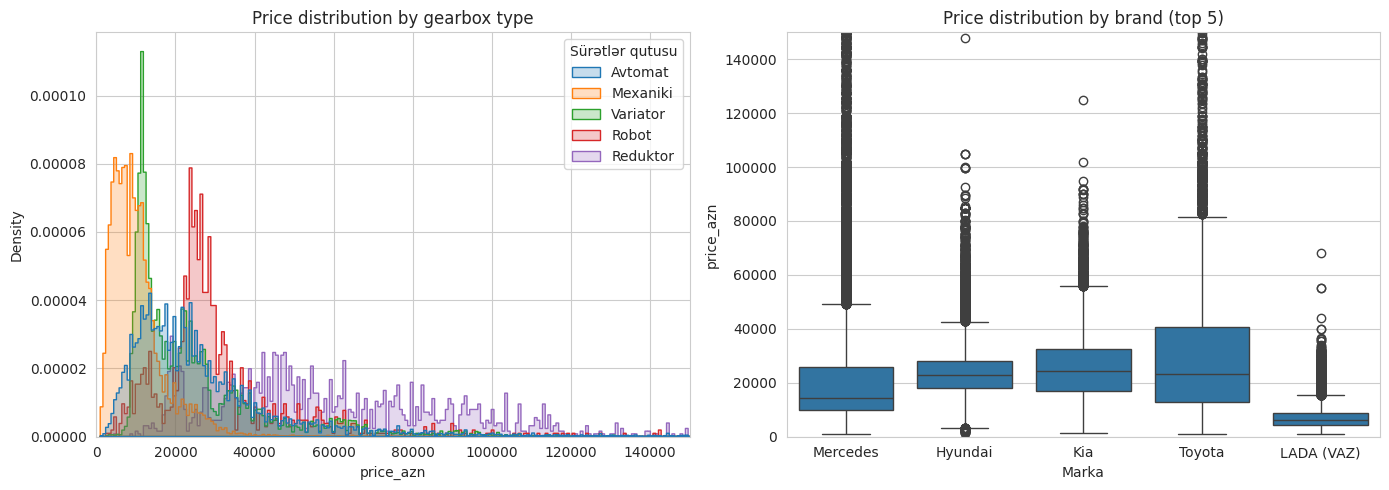

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_clean, x="price_azn", hue="Sürətlər qutusu",
             element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_xlim(0, 150000)
axes[0].set_title("Price distribution by gearbox type")

sns.boxplot(data=df_clean[df_clean["Marka"].isin(top5_brands)], x="Marka", y="price_azn",
            order=top5_brands, ax=axes[1])
axes[1].set_ylim(0, 150000)
axes[1].set_title("Price distribution by brand (top 5)")

plt.tight_layout()
plt.show()


## Final Check

**What I did to clean the data:**
1. Removed duplicate scrapes.
2. Converted 3 currencies into AZN using fixed rates.
3. Removed non-car vehicles.
4. Removed prices under 1,000 AZN.
5. Final clean data: 149,478 unique car listings.

**What I found:**
- All the price distributions are strongly right-skewed, so I'll need to check normality carefully in later checkpoints.
- Automatic cars have a median price (22,000 AZN) about 2.5x higher than manual cars (8,900 AZN).
- All-wheel-drive cars ("Tam") have a much higher median price (32,000 AZN) than front/rear-wheel drive, good candidate for another test.
- By brand: LADA (VAZ) has the lowest median price, the other 4 brands are closer to each other, good for comparing with ANOVA.